# Practica 1 Conociendo tus datos
## Parte I — Carga y Limpieza de Datos
### Paso 1: Importar librerias


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

### Paso 2 : Cargar dataset

In [284]:
#Nombres en las culumnas del dataset

cols = [
    "Alcohol","Malic acid","Ash","Alcalinity of ash",
    "Magnesium","Total phenols","Flavanoids",
    "Nonflavanoid phenols","Proanthocyanins",
    "Color intensity","Hue",
    "OD280/OD315 of diluted wines","Proline"
]

df = pd.read_csv("wine.data", header=None, names=cols)

print(df.iloc[:5, :])


   Alcohol  Malic acid   Ash  Alcalinity of ash  Magnesium  Total phenols  \
1    14.23        1.71  2.43               15.6        127           2.80   
1    13.20        1.78  2.14               11.2        100           2.65   
1    13.16        2.36  2.67               18.6        101           2.80   
1    14.37        1.95  2.50               16.8        113           3.85   
1    13.24        2.59  2.87               21.0        118           2.80   

   Flavanoids  Nonflavanoid phenols  Proanthocyanins  Color intensity   Hue  \
1        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
1        3.24                  0.30             2.81             5.68  1.03   
1        3.49                  0.24             2.18             7.80  0.86   
1        2.69                  0.39             1.82             4.32  1.04   

   OD280/OD315 of diluted wines  Proline  
1                  

### Pase 3: Liempieza de datos

In [285]:
# Reemplazar '?' por NaN y revisar nulos

print("Tamaño original:", df.shape)

# Para observar los nulos por culumna
print(df.isna().sum())





Tamaño original: (178, 13)
Alcohol                         0
Malic acid                      0
Ash                             0
Alcalinity of ash               0
Magnesium                       0
Total phenols                   0
Flavanoids                      0
Nonflavanoid phenols            0
Proanthocyanins                 0
Color intensity                 0
Hue                             0
OD280/OD315 of diluted wines    0
Proline                         0
dtype: int64


## Parte II — Identificación de Atributos
### Paso 4 — Revisar tipo de datos detectados por pandas

In [286]:
#Identificar que tipo de datos maneja cada columna
df.dtypes

Alcohol                         float64
Malic acid                      float64
Ash                             float64
Alcalinity of ash               float64
Magnesium                         int64
Total phenols                   float64
Flavanoids                      float64
Nonflavanoid phenols            float64
Proanthocyanins                 float64
Color intensity                 float64
Hue                             float64
OD280/OD315 of diluted wines    float64
Proline                           int64
dtype: object

### Paso 5: Clasificación Teórica
| Nombre del atributo | Tipo teórico | Tipo detectado por pandas | Número de valores únicos |
|----------------------|--------------|---------------------------|--------------------------|
| Alcohol | Numérico Continuo| float64 | 126 |
| Malic acid | Numérico Continuo | float64 | 133 |
| Ash | Numérico Continuo| float64 | 79 |
| Alcalinity of ash | Numérico Continuo | float64 | 63 |
| Magnesium | Numérico Discreto | int64 | 53 |
| Total phenols | Numérico Continuo | float64 | 97 |
| Flavanoids | Numérico Continuo | float64 | 132 |
| Nonflavanoid phenols | Numérico Continuo | float64 | 39 |
| Proanthocyanins | Numérico Continuo| float64 | 101 |
| Color intensity | Numérico  Continuo| float64 | 132 |
| Hue | Numérico Continuo | float64 | 78 |
| OD280/OD315 of diluted wines | Numérico  Continuo| float64 | 122 |
| Proline | Numérico Discreto| int64 | 121 |


In [287]:
df.nunique()

Alcohol                         126
Malic acid                      133
Ash                              79
Alcalinity of ash                63
Magnesium                        53
Total phenols                    97
Flavanoids                      132
Nonflavanoid phenols             39
Proanthocyanins                 101
Color intensity                 132
Hue                              78
OD280/OD315 of diluted wines    122
Proline                         121
dtype: int64

## Parte III — Estadística Descriptiva
### Paso 6: Estadística general

In [288]:
df.describe()

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Paso 7: Tendencia Central

In [289]:
tc = df.iloc[:,:3]
promedio = tc.mean()
print(promedio)


Alcohol       13.000618
Malic acid     2.336348
Ash            2.366517
dtype: float64


In [290]:
mediana = tc.median()
print(mediana)

Alcohol       13.050
Malic acid     1.865
Ash            2.360
dtype: float64


In [291]:
moda = tc.mode()
print(moda)

   Alcohol  Malic acid   Ash
0    12.37        1.73  2.28
1    13.05         NaN  2.30


### Paso 8: Dispersión

In [292]:
alcohol = df.iloc[:, 0]

minimo = alcohol.min()
maximo = alcohol.max()
Q1 = alcohol.quantile(0.25)
Q3 = alcohol.quantile(0.75)
IQR=  Q3-Q1
varianza = alcohol.var()
std = alcohol.std()

print("Rango: [", minimo,",",maximo, "]")
print('Q1 :',Q1)
print('Q3 :', Q3)
print("IQR: ",IQR)
print("Varianza: ",varianza)
print("Desviacion estandar: ",std)


Rango: [ 11.03 , 14.83 ]
Q1 : 12.362499999999999
Q3 : 13.6775
IQR:  1.3150000000000013
Varianza:  0.6590623278105763
Desviacion estandar:  0.8118265380058577


### Paso 9: Frecuencias en categóricas


In [293]:

phenols = df["Nonflavanoid phenols"]
hue = df["Hue"]
top10phe = phenols.value_counts().head(10)
top10hue = hue.value_counts().head(10)
print("Top 10 valores repetidos en phenol: ",top10phe)
print("Top 10 valores repetidos en hue: ",top10hue)

Top 10 valores repetidos en phenol:  Nonflavanoid phenols
0.26    11
0.43    11
0.29    10
0.32     9
0.30     8
0.34     8
0.40     8
0.27     8
0.37     8
0.24     7
Name: count, dtype: int64
Top 10 valores repetidos en hue:  Hue
1.04    8
1.23    7
1.12    6
1.25    5
0.96    5
0.89    5
0.57    5
1.05    4
0.86    4
1.07    4
Name: count, dtype: int64


## Parte IV — Visualización de Datos
### Paso 10: Histogramas

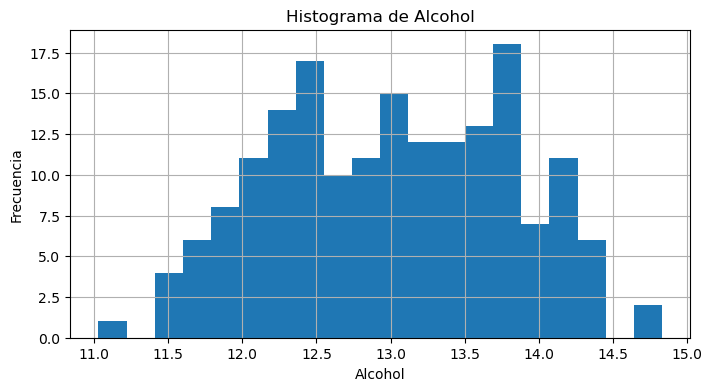

In [294]:
df["Alcohol"].hist(bins=20)
plt.xlabel("Alcohol")
plt.ylabel("Frecuencia")
plt.title("Histograma de Alcohol")
plt.show()

### Paso 11: Densidad (KDE)


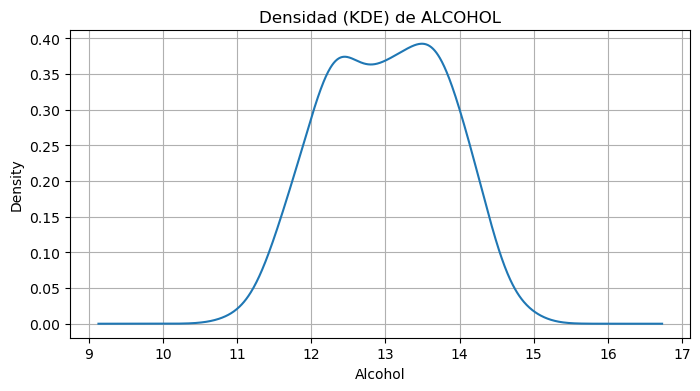

In [295]:
# 6.2 Densidad (KDE)
df["Alcohol"].plot.kde()
plt.title("Densidad (KDE) de ALCOHOL")
plt.xlabel("Alcohol")
plt.show()


### Paso 12: Boxplot

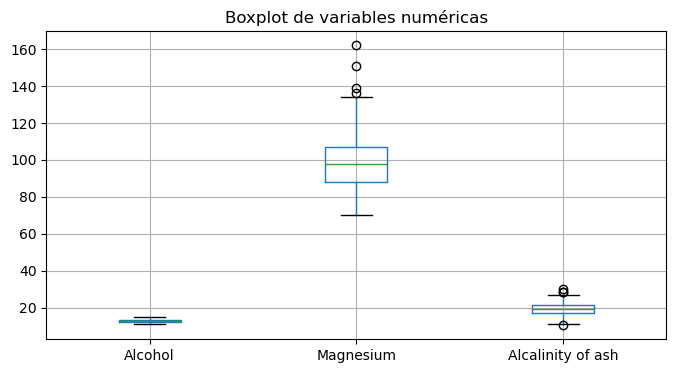

In [298]:
df.boxplot(column=["Alcohol", "Magnesium", "Alcalinity of ash"])
plt.title("Boxplot de variables numéricas")
plt.show()






### Paso 13:  Scatter

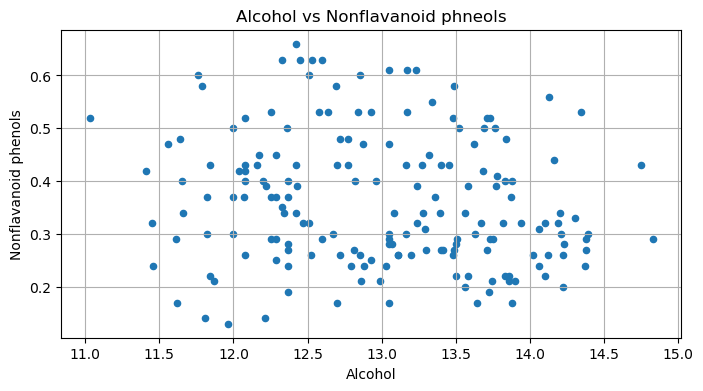

In [299]:
df.plot.scatter(x="Alcohol", y="Nonflavanoid phenols")
plt.title("Alcohol vs Nonflavanoid phneols")
plt.show()

### Paso 14: Gráfica de Barras

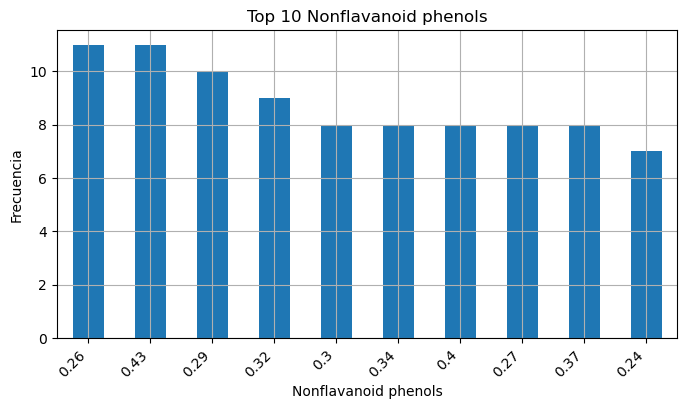

In [301]:
top = df["Nonflavanoid phenols"].value_counts().head(10)
top.plot(kind="bar")
plt.title("Top 10 Nonflavanoid phenols")
plt.xlabel("Nonflavanoid phenols")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.show()

## Parte V — Medición de Similitud y Disimilitud
### Paso 15: Selección aleatoria de muestra
### Paso 16: Implementar función Minkowski


In [302]:
muestra = df.sample(10, random_state=7).reset_index(drop=True)

def minkowski(a, b, p=2):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    return np.sum(np.abs(a-b)**p)**(1/p)

num_cols = ["Alcalinity of ash","Alcohol","Color intensity"]

a = muestra.loc[0, num_cols]
b = muestra.loc[1, num_cols]

print("Fila 0:", list(a))
print("Fila 1:", list(b))
print("Manhattan (p=1):", minkowski(a, b, p=1))
print("Euclidiana (p=2):", minkowski(a, b, p=2))

Fila 0: [21.5, 12.87, 7.65]
Fila 1: [15.5, 13.28, 4.6]
Manhattan (p=1): 9.46
Euclidiana (p=2): 6.74318915647485


### Paso 17: Matriz de Distancias

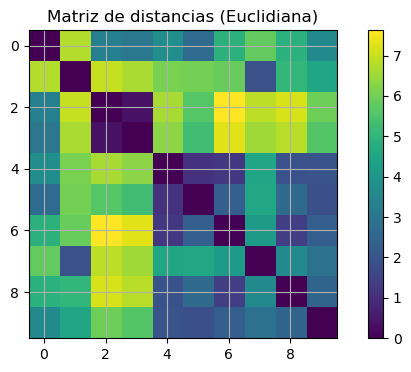

In [303]:

def matriz_distancias_numericas(df_small, cols, p=2):
    X = df_small[cols].to_numpy(dtype=float)
    n = X.shape[0]
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = minkowski(X[i], X[j], p=p)
    return pd.DataFrame(D)

D_euclid = matriz_distancias_numericas(muestra, num_cols, p=2)

plt.imshow(D_euclid.values)
plt.title("Matriz de distancias (Euclidiana)")
plt.colorbar()
plt.show()



### Paso 18: Distancias para binarios/nominales (Hamming y Jaccard)

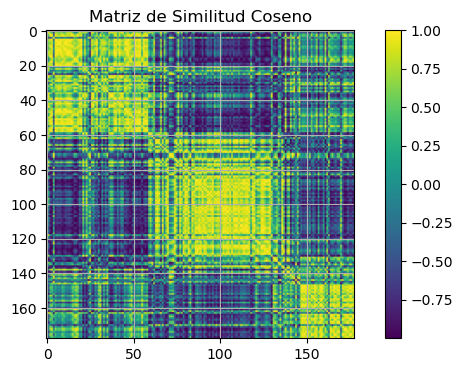

In [306]:
X = df[num_cols].to_numpy(dtype=float)

# Estandarización Z-score
Xz = (X - X.mean(axis=0)) / X.std(axis=0)

def cosine_sim(u, v):
    denom = np.linalg.norm(u) * np.linalg.norm(v)
    return 0 if denom == 0 else np.dot(u, v) / denom
n = Xz.shape[0]
S = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        S[i, j] = cosine_sim(Xz[i], Xz[j])

S_df = pd.DataFrame(S)

plt.figure()
plt.imshow(S_df.values)
plt.title("Matriz de Similitud Coseno")
plt.colorbar()
plt.show()